# **Analisi del dataset Employee Attrition**

Dal dataset vogliamo prevvedere la probabilità dell'abbandono da parte dei dipendenti dipendenti.

Il tipo di problema è una classificazione binaria:


*   Yes = il dipendente ha lasciato l'azienda
*   No = il dipendente è rimasto



In [1]:
#importiamo le librerie
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Carichiamo i dati del dataset.

In [2]:
#carichiamo i dati
employee_attrition = pd.read_csv("/content/Employee_Attrition.csv", sep=",")
print (employee_attrition)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

## **Numero colonne e righe**

In [3]:
#conto il numero di righe e colonne del dataset
num_righe = employee_attrition.shape[0]
num_colonne = employee_attrition.shape[1]
print(f"Numero righe {num_righe}")
print(f"Numero colonne {num_colonne}")

Numero righe 1470
Numero colonne 35


Il dataset ha 1470 righe e 35 colonne.

## **Stuttura**

In [4]:
employee_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
#facciamo in modo da poter visuaizzare le intere colonne
from google.colab.data_table import DataTable
DataTable.max_columns = 35

In [6]:
#vediamo concretamente i dati delle prime 5 righe
employee_attrition.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Pulizia del dataset**

## **Valori mancanti**

In [7]:
#cerco i valori mancanti
employee_attrition.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Il dataset non presenta valori mancanti.

## **Valori non utili per l'analisi**

In [8]:
employee_attrition["Over18"].value_counts()

,count
Over18,
Y,1470


In [9]:
employee_attrition.drop('Over18', axis=1, inplace=True)

Tutti i dipendenti sono maggiorenni, quindi la colonna Over18 non contiene informazioni utili per la previsione.

In [10]:
employee_attrition.drop('EmployeeCount', axis=1, inplace=True)

EmployeeCount non presenta dati utili al fine della previsione in quanto ci dice solo che in quella riga si trova 1 lavoratore.

In [11]:
employee_attrition.drop('EmployeeNumber', axis=1, inplace=True)

EmployeeNumber ci specifica il numero identificativo del dipendente e non è un valore che serve al fine della previsione, **può essere utile solo dopo l'addestramento del modello** per identificare i dipendenti più a rischio di abbandono.

In [12]:
#vediamo se 80 è l'unico dato per tutti i dipendenti
employee_attrition["StandardHours"].nunique()

1

In [13]:
employee_attrition.drop('StandardHours', axis=1, inplace=True)

Possiamo cancellare la colonna StandardHours in quanto tutti i dipendenti presentano 80 come orario standard e abbiamo già la colonna OverTime che ci dice quali dipendenti hanno lavorato di più.

## **Togliere le incosistenze**

In [14]:
#creo un df originale
df_originale = employee_attrition.copy()

In [15]:
# applico lo strip per togliere gli spazi bianchi
# e lower per convertire tutto in minuscolo
employee_attrition[employee_attrition.select_dtypes(include='object').columns] = (
    employee_attrition.select_dtypes(include='object').apply(lambda x: x.str.strip().str.lower())
)

In [16]:
#controllo se ci sono state modifiche
(df_originale != employee_attrition).any().any()

np.True_

In [17]:
#stampo le colonne con modifiche
for col in employee_attrition.select_dtypes(include='object').columns:
    if not df_originale[col].equals(employee_attrition[col]):
        print(col)

Attrition
BusinessTravel
Department
EducationField
Gender
JobRole
MaritalStatus
OverTime


Ho convertito tutto il testo in modo da essere certa di non avere inconsitenze nella scrittura.

## **Dati sospetti**

In [18]:
employee_attrition.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Ossevando il dataset non sembrano esserci dati sospetti o esagerati, gli intervalli numerici sono logici.

## **Trovare i duplicati**

In [19]:
employee_attrition.duplicated().sum()

np.int64(0)

Non ci sono osservazioni duplicate.

# **Analisi delle variabili**

In [20]:
#vediamo concretamente i dati delle prime 5 righe dopo aver eliminato le colonne
employee_attrition.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,yes,travel_rarely,1102,sales,1,2,life sciences,2,female,...,3,1,0,8,0,1,6,4,0,5
1,49,no,travel_frequently,279,research & development,8,1,life sciences,3,male,...,4,4,1,10,3,3,10,7,1,7
2,37,yes,travel_rarely,1373,research & development,2,2,other,4,male,...,3,2,0,7,3,3,0,0,0,0
3,33,no,travel_frequently,1392,research & development,3,4,life sciences,4,female,...,3,3,0,8,3,3,8,7,3,0
4,27,no,travel_rarely,591,research & development,2,1,medical,1,male,...,3,4,1,6,3,3,2,2,2,2


## **Studiare la variabile target**

In [21]:
employee_attrition["Attrition"].value_counts()

,count
Attrition,
no,1233
yes,237


Sappiamo che 1233 lavoratori sono rimasti mentre 237 sono andati via.

In [22]:
employee_attrition["Attrition"].value_counts(normalize=True)*100

,proportion
Attrition,
no,83.877551
yes,16.122449


Quasi 84% dei dipendenti sono rimasti.

## **Outlier**

In [23]:
#Trasformo Attrition in un targhet numerico
employee_attrition["Attrition"]= employee_attrition["Attrition"].map({
    "no": 0,
    "yes": 1
})

In [24]:
#Seleziono solo l'etichetta delle colonne non numeriche
employee_attrition.select_dtypes(include="object").columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

### **One-Hot Encoding**

In [25]:
#One-Hot Encoding delle categorie non numeriche in quanto non vi è
#un ordine intrinseco dei dati
employee_attrition_encoded = pd.get_dummies(
    employee_attrition,
    columns = [
        "BusinessTravel",
        "Department",
        "EducationField",
        "Gender",
        "JobRole",
        "MaritalStatus",
        "OverTime"
    ],
    drop_first=True
)

In [26]:
#Controllo che sia stato tutto trasformato
employee_attrition_encoded.dtypes

,0
Age,int64
Attrition,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EnvironmentSatisfaction,int64
HourlyRate,int64
JobInvolvement,int64
JobLevel,int64
JobSatisfaction,int64


In [27]:
#seleziono le colonne numeriche
num_cols = employee_attrition_encoded.select_dtypes(
    include= ["int64", "float64"]
).columns

print(num_cols.tolist())
#Le colonne booleane non ci servono in quanto non ci sono outlier

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### **IOR (Interqurtile Range)**

In [28]:
#Applico la regola IQR
outliners_summary = []

for col in num_cols:
  Q1 = employee_attrition_encoded[col].quantile (0.25)
  Q3 = employee_attrition_encoded[col].quantile (0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  n_outliners = ((employee_attrition_encoded[col]< lower) |
   (employee_attrition_encoded[col] > upper)).sum()

#Seleziono solo le variabili con outliner
  if n_outliners > 0:
    perc = (n_outliners / len(employee_attrition_encoded)) *100

    outliners_summary.append([
        col,
        n_outliners,
        round(perc, 2)
    ])

#Creo una tabella per facilitare la visualizzazione
outliner_df = pd.DataFrame (
    outliners_summary,
    columns = [
        "Variabile",
        "Numero_Outlier",
        "Percentuale_Outlier"
    ]
)

outliner_df

,Variabile,Numero_Outlier,Percentuale_Outlier
0,Attrition,237,16.12
1,MonthlyIncome,114,7.76
2,NumCompaniesWorked,52,3.54
3,PerformanceRating,226,15.37
4,StockOptionLevel,85,5.78
5,TotalWorkingYears,63,4.29
6,TrainingTimesLastYear,238,16.19
7,YearsAtCompany,104,7.07
8,YearsInCurrentRole,21,1.43
9,YearsSinceLastPromotion,107,7.28


### ***0. MonthlyIncome***

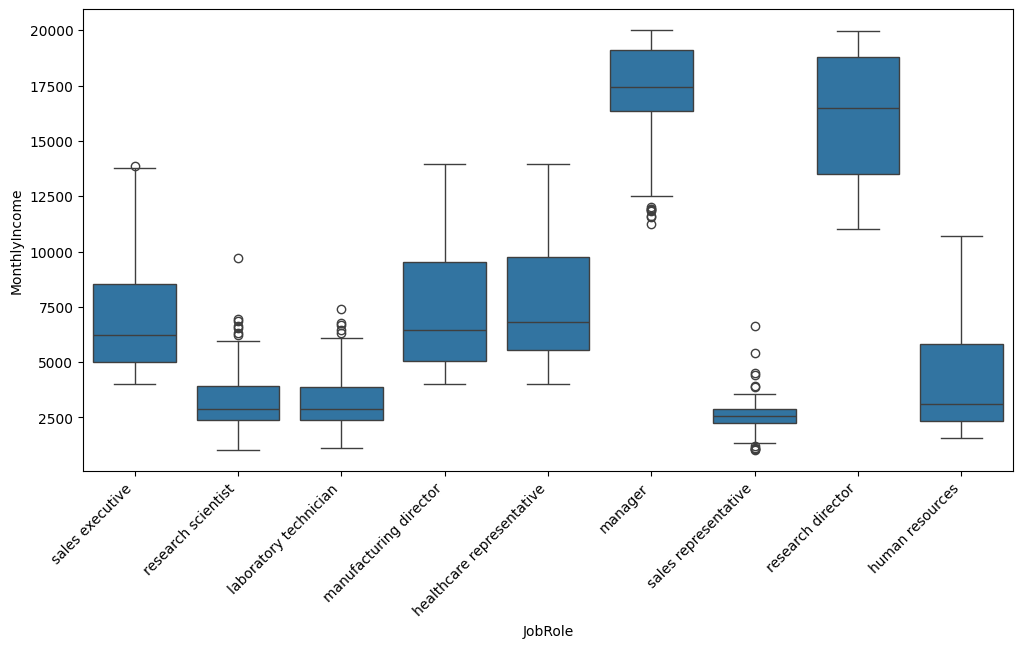

In [29]:
#Metto in relazione lo stipendio mensile con il ruolo ricoperto
employee_attrition.groupby("JobRole")["MonthlyIncome"].describe()

plt.figure(figsize=(12,6))
sns.boxplot(
    data=employee_attrition,
    x="JobRole",
    y="MonthlyIncome"
)
plt.xticks(rotation=45, ha="right")

plt.show()

Gli outlier appartengono ai ruoli:
- Sales Executive
- Research Scientist
- Laboratory Technician
- Manager
- Sales Representative

Si presentano quindi sia nei lavoratori con uno stipendio mensile alto (Manager) che quelli medi e bassi.
La presenza degli outlier potrebbe essere spiegata da altre variabili, come le ore extra lavorate, una migliore o peggiore performance.

Si presentano comunque come outlier plausibili da mantenere.

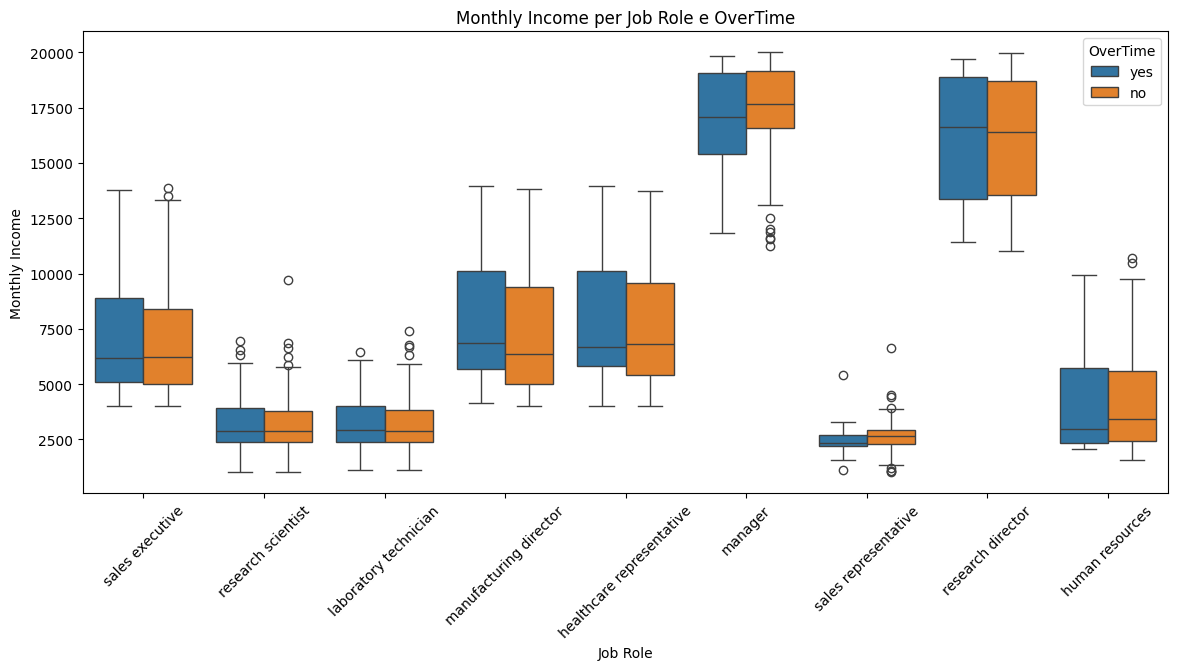

In [30]:
#Metto in relazione lo stipendio mensile e il ruolo lavorativo con la presenza
#o no delle ore di straordinario svolto
plt.figure(figsize=(14,6))

sns.boxplot(
    data=employee_attrition,
    x="JobRole",
    y="MonthlyIncome",
    hue="OverTime"
)

plt.xticks(rotation=45)
plt.title("Monthly Income per Job Role e OverTime")
plt.xlabel("Job Role")
plt.ylabel("Monthly Income")

plt.show()

Sales Executive

Nei Sales Executive gli outlier relativi agli stipendi più elevati sembrano concentrarsi prevalentemente tra i lavoratori che svolgono straordinari. Questo potrebbe suggerire una relazione tra overtime e livelli retributivi più elevati, anche se sarebbero necessarie ulteriori analisi per confermarla.

Research Scientist

Nella categoria Research Scientist gli outlier salariali sono presenti sia tra i lavoratori che svolgono straordinari sia tra quelli che non li svolgono. Ciò suggerisce che l'overtime non sia l'unico fattore associato alle differenze retributive; potrebbero intervenire variabili come anzianità, esperienza o livello professionale.

Laboratory Technician

I Laboratory Technician presentano outlier salariali in entrambe le categorie, ma la presenza di valori estremi risulta più evidente tra coloro che svolgono straordinari. Questo potrebbe indicare una maggiore variabilità retributiva all'interno del gruppo che effettua overtime.

Manufacturing Director e Healthcare Representative

Per queste due categorie non emergono outlier significativi nella distribuzione degli stipendi. La retribuzione appare quindi relativamente omogenea rispetto alle altre categorie professionali.

Manager

Tra i Manager si osservano alcuni outlier corrispondenti a stipendi relativamente più bassi nei lavoratori che svolgono straordinari, mentre tali valori non compaiono nel gruppo che non effettua overtime. Tale fenomeno potrebbe essere associato ad altri fattori organizzativi o professionali, come anzianità, responsabilità specifiche o valutazioni delle performance.

Sales Representative

I Sales Representative presentano outlier sia superiori sia inferiori in entrambi i gruppi (overtime e non overtime). La presenza di valori estremi in entrambe le condizioni suggerisce che la variabilità salariale sia probabilmente influenzata da fattori ulteriori rispetto allo svolgimento di straordinari.

Research Director

Non si osservano outlier significativi per nessuna delle due categorie considerate. La distribuzione degli stipendi appare quindi piuttosto stabile all'interno del ruolo.

Human Resources

Nella categoria Human Resources emerge un outlier relativo a uno stipendio elevato tra i lavoratori che svolgono straordinari. Poiché si tratta di un caso isolato, non è possibile attribuire il fenomeno esclusivamente all'overtime, ma il dato merita ulteriori approfondimenti.

L'analisi degli outlier della variabile MonthlyIncome ha evidenziato la presenza di valori estremi in alcuni ruoli professionali. Tali osservazioni risultano plausibili dal punto di vista aziendale e non appaiono riconducibili a errori di registrazione o misurazione. Pertanto, **gli outlier sono stati mantenuti nel dataset in quanto rappresentativi della reale distribuzione degli stipendi**.

### ***1. NumCompaniesWorked***

In [31]:
employee_attrition["NumCompaniesWorked"].value_counts().sort_index()

,count
NumCompaniesWorked,
0,197
1,521
2,146
3,159
4,139
5,63
6,70
7,74
8,49


<Axes: xlabel='NumCompaniesWorked', ylabel='Count'>

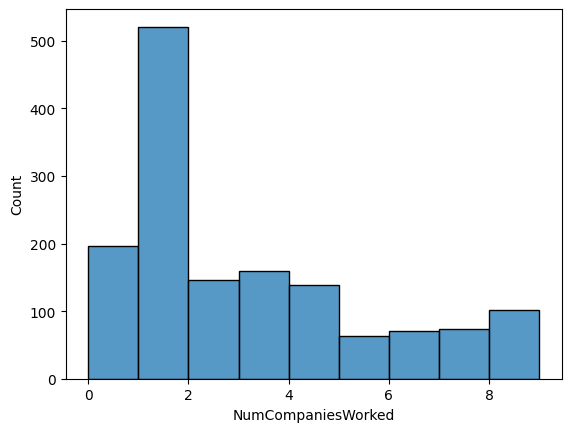

In [32]:
sns.histplot(x=employee_attrition["NumCompaniesWorked"], binwidth=1)

La variabile NumCompaniesWorked presenta 52 outlier identificati tramite metodo IQR. Tuttavia i valori estremi risultano plausibili dal punto di vista lavorativo e sono **stati mantenuti nel dataset**.

### ***2. PerformanceRating***

In [33]:
employee_attrition["PerformanceRating"].value_counts()

,count
PerformanceRating,
3,1244
4,226


La variabile PerformanceRating presenta 226 osservazioni identificate come outlier dal metodo IQR (15,37% del dataset). Tuttavia, trattandosi di una variabile discreta con soli due livelli di valutazione (3 e 4), tali valori rappresentano categorie legittime e non anomalie. Pertanto **non sono stati effettuati interventi di rimozione o trasformazione**.

### ***3. StockOptionLevel***

In [34]:
employee_attrition["StockOptionLevel"].value_counts().sort_index()

,count
StockOptionLevel,
0,631
1,596
2,158
3,85


La variabile StockOptionLevel presenta 85 osservazioni identificate come outlier (5,78%) tramite il metodo IQR. Tuttavia, trattandosi di una variabile discreta ordinale con valori compresi tra 0 e 3, tali osservazioni rappresentano livelli validi di stock option assegnate ai dipendenti e non anomalie nei dati. Di conseguenza, **non sono state effettuate modifiche o rimozioni**.

### ***4. TotalWorkingYears***

In [35]:
employee_attrition["TotalWorkingYears"].describe()

,TotalWorkingYears
count,1470.000000
mean,11.279592
std,7.780782
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,40.000000


La variabile TotalWorkingYears presenta 63 osservazioni identificate come outlier (4,2%) tramite il metodo IQR. L'analisi dei valori estremi mostra che tali osservazioni corrispondono a dipendenti con un'elevata anzianità lavorativa e non a errori di registrazione. **Pertanto gli outlier sono stati mantenuti nel dataset**.

### ***5. TrainingTimeLastYear***

In [36]:
employee_attrition["TrainingTimesLastYear"].value_counts().sort_index()

,count
TrainingTimesLastYear,
0,54
1,71
2,547
3,491
4,123
5,119
6,65


La variabile TrainingTimesLastYear presenta 238 osservazioni identificate come outlier (16,19%) tramite il metodo IQR. Tuttavia, trattandosi di una variabile discreta che rappresenta il numero di attività formative svolte nell'ultimo anno, i valori estremi osservati risultano plausibili e coerenti con il contesto aziendale. Pertanto **non sono state effettuate modifiche o rimozioni**.

### ***6. YearsAtCompany***

In [37]:
employee_attrition["YearsAtCompany"].describe()

,YearsAtCompany
count,1470.000000
mean,7.008163
std,6.126525
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,40.000000


La variabile YearsAtCompany presenta 104 osservazioni identificate come outlier (7,0%) tramite il metodo IQR. L'analisi dei valori estremi evidenzia che tali osservazioni rappresentano dipendenti con una permanenza particolarmente elevata nell'azienda. **Poiché i valori risultano coerenti e plausibili, gli outlier sono stati mantenuti nel dataset**.

### ***7. YearsInCurrentRole***

In [38]:
employee_attrition["YearsInCurrentRole"].value_counts().sort_index()

,count
YearsInCurrentRole,
0,244
1,57
2,372
3,135
4,104
5,36
6,37
7,222
8,89


La variabile YearsInCurrentRole presenta 21 osservazioni identificate come outlier (1,43%) tramite il metodo IQR. L'analisi dei valori estremi mostra che tali osservazioni corrispondono a dipendenti che hanno ricoperto lo stesso ruolo per un numero elevato di anni. **Poiché i valori risultano plausibili e coerenti con il contesto aziendale, gli outlier sono stati mantenuti nel dataset**.

### ***8. YearsSinceLastPromotion***

In [39]:
employee_attrition["YearsSinceLastPromotion"].value_counts().sort_index()

,count
YearsSinceLastPromotion,
0,581
1,357
2,159
3,52
4,61
5,45
6,32
7,76
8,18


La variabile YearsSinceLastPromotion presenta 107 osservazioni identificate come outlier (7,28%) tramite il metodo IQR. L'analisi dei valori estremi evidenzia dipendenti che non hanno ricevuto promozioni per un periodo particolarmente lungo.

Possono rappresentare:

- dipendenti che non ricevono promozioni da molto tempo;
- dipendenti vicini alla pensione;
- ruoli con poche opportunità di avanzamento.

Poiché tali valori risultano plausibili nel contesto organizzativo e potenzialmente rilevanti per l'analisi del turnover, gli outlier sono stati mantenuti nel dataset.

### ***9. YearsWithCurrManager***

In [40]:
employee_attrition["YearsWithCurrManager"].value_counts().sort_index()

,count
YearsWithCurrManager,
0,263
1,76
2,344
3,142
4,98
5,31
6,29
7,216
8,107


La variabile YearsWithCurrManager presenta 14 osservazioni identificate come outlier (0,9%) tramite il metodo IQR. Tali osservazioni rappresentano dipendenti che lavorano con lo stesso responsabile da un numero particolarmente elevato di anni.

È molto probabile che questi 14 casi siano persone che:

- lavorano da molti anni con lo stesso manager;
- fanno parte di team molto stabili;
- hanno una lunga permanenza aziendale.

Poiché i valori risultano coerenti e plausibili nel contesto aziendale, **gli outlier sono stati mantenuti nel dataset**.

L'analisi degli outlier mediante il metodo IQR ha evidenziato la presenza di valori estremi in diverse variabili. L'ispezione dei dati ha mostrato che tali osservazioni risultano coerenti con il fenomeno studiato e rappresentano casi reali (ad esempio elevata anzianità lavorativa, lunga permanenza aziendale o valutazioni di performance particolari). Non essendo emerse evidenze di errori di registrazione o misurazione, gli outlier sono stati mantenuti nel dataset per preservare l'informazione disponibile e supportare le successive analisi predittive.

# **Ipotesi sul dataset**

### **Overtime e Attrition**

H1. I dipendenti che hanno strordinari (Overtime) abbandonano di più?

In [41]:
#attrition no = 0, yes =1
#utilizzando la version encoded uso OverTime_yes
pd.crosstab(
    employee_attrition_encoded["OverTime_yes"],
    employee_attrition_encoded["Attrition"],
    normalize="index"
) * 100

Attrition,0,1
OverTime_yes,,
False,89.563567,10.436433
True,69.471154,30.528846


Il 31% dei dipendenti che fanno straordinari lascia l'azienda, contro solo l'11% di chi non li fa.

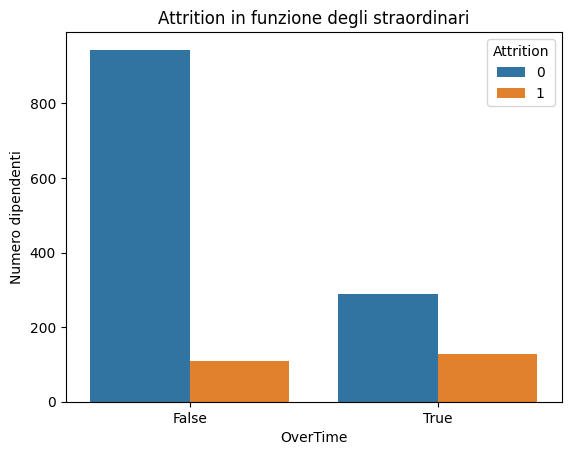

In [42]:
#visualizzo i dati
#attrition no = 0, yes =1
sns.countplot(
    data=employee_attrition_encoded,
    x="OverTime_yes",
    hue="Attrition"
)

plt.title("Attrition in funzione degli straordinari")
plt.xlabel("OverTime")
plt.ylabel("Numero dipendenti")
plt.show()

### **MonthlyIncome e Attrition**

H2. I dipendenti con reddito mensile più basso lasciano di più?

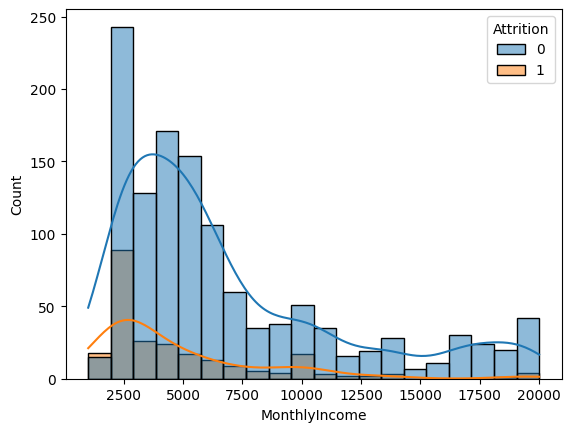

In [43]:
sns.histplot(
    data=employee_attrition_encoded,
    x="MonthlyIncome",
    hue="Attrition",
    kde=True,
    multiple="layer"
)
plt.show()

L'analisi della distribuzione del reddito mensile mostra che i dipendenti che hanno lasciato l'azienda tendono a concentrarsi nelle fasce salariali più basse. La distribuzione dell'attrition risulta infatti spostata verso valori di reddito inferiori rispetto a quella dei dipendenti rimasti. Questo suggerisce una possibile relazione tra bassa retribuzione e maggiore probabilità di abbandono dell'azienda.

### **MaritalStatus e Attrition**

H3. I dipendenti single abbandonano di più?

In [44]:
employee_attrition_encoded.groupby(
    "MaritalStatus_single"
)["Attrition"].mean() * 100

,Attrition
MaritalStatus_single,
False,11.700000
True,25.531915


I dipendenti single presentano un tasso di attrition superiore rispetto ai dipendenti non single. Una possibile spiegazione è che abbiano minori vincoli familiari e una maggiore disponibilità a cambiare impiego o città per cogliere nuove opportunità professionali.

### **Age and Attrition**

H4. I dipendenti più giovani lasciano più frequentemente?

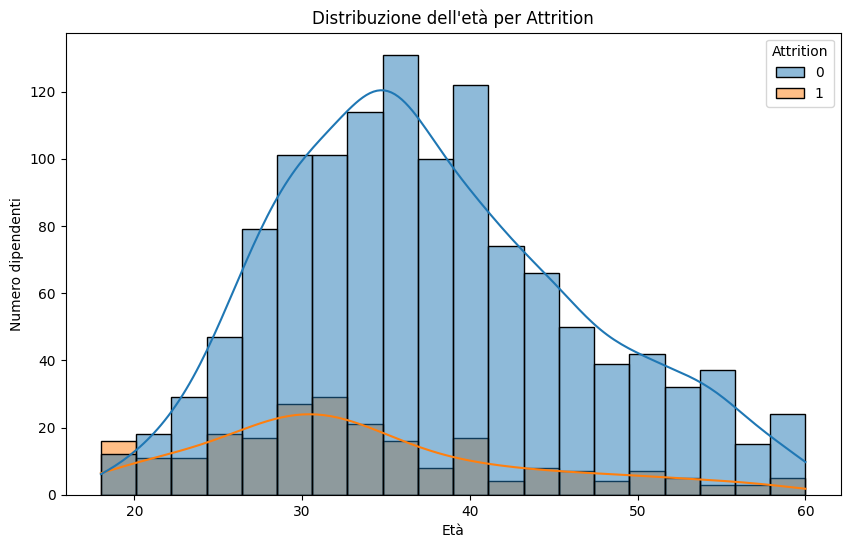

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=employee_attrition_encoded,
    x="Age",
    hue="Attrition",
    kde=True,
    bins=20,
    multiple="layer"
)

plt.title("Distribuzione dell'età per Attrition")
plt.xlabel("Età")
plt.ylabel("Numero dipendenti")
plt.show()

I dipendenti che hanno lasciato l'azienda risultano mediamente più giovani rispetto a quelli rimasti. La distribuzione dell'età mostra una maggiore concentrazione di casi di attrition nelle fasce anagrafiche più basse (sotto i 40 anni, compreso), suggerendo che i lavoratori più giovani siano maggiormente propensi a cambiare impiego alla ricerca di migliori opportunità di carriera, crescita professionale o condizioni lavorative più favorevoli.

### **BusinessTravel e Attrition**

H5. Chi viaggia frequentemente abbandona di più?

In [46]:
employee_attrition_encoded.groupby(
    "BusinessTravel_travel_frequently"
)["Attrition"].mean() * 100

,Attrition
BusinessTravel_travel_frequently,
False,14.082146
True,24.909747


I dipendenti che viaggiano frequentemente per lavoro mostrano un tasso di attrition superiore (quasi 25%) rispetto agli altri dipendenti (circa il 14%). Una possibile spiegazione è che i frequenti spostamenti possano incidere negativamente sull'equilibrio tra vita privata e lavoro, aumentando il rischio di insoddisfazione e di abbandono dell'azienda.

### **JobSatisfaction e Attrition**

H6. La bassa soddisfazione lavorativa è correlata con l'abbandono?

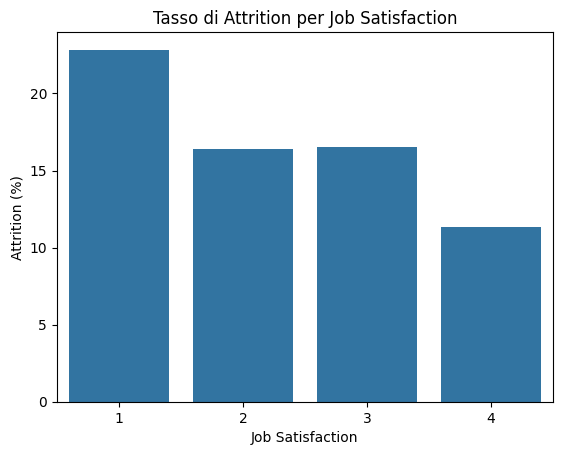

In [47]:
attrition_rate = (
    employee_attrition_encoded
    .groupby("JobSatisfaction")["Attrition"]
    .mean() * 100
)

sns.barplot(
    x=attrition_rate.index,
    y=attrition_rate.values
)

plt.title("Tasso di Attrition per Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition (%)")
plt.show()

L'analisi evidenzia una relazione inversa tra soddisfazione lavorativa e attrition. I dipendenti con livelli più bassi di Job Satisfaction mostrano una maggiore probabilità di lasciare l'azienda, mentre coloro che dichiarano livelli elevati di soddisfazione tendono a rimanere più a lungo. Questo suggerisce che la soddisfazione lavorativa rappresenti un fattore rilevante nella retention del personale.

### **PerformanceRating e Attrition**

H7. I dipendenti con valutazioni delle prestazioni diverse mostrano tassi di attrition differenti?

In [48]:
employee_attrition_encoded.groupby(
    "PerformanceRating"
)["Attrition"].mean() * 100

,Attrition
PerformanceRating,
3,16.077170
4,16.371681


La variabile PerformanceRating presenta una bassissima variabilità, essendo concentrata quasi esclusivamente nei valori 3 e 4. Questa caratteristica potrebbe limitarne il potere esplicativo e la sua utilità nella previsione dell'attrition.

### **StockOptionLevel e Attrition**

H8. Chi ha opzioni sulle azioni (StockOptionLevel alto) è più fedele all'azienda?

In [49]:
#0 = nessuna stock option
#1 = livello basso
#2 = livello medio
#3 = livello alto
employee_attrition_encoded.groupby(
    "StockOptionLevel"
)["Attrition"].mean() * 100

,Attrition
StockOptionLevel,
0,24.405705
1,9.395973
2,7.594937
3,17.647059


L'analisi mostra che i dipendenti privi di stock option presentano il più alto tasso di attrition (24,4%). I livelli 1 e 2 sono associati a una significativa riduzione dell'abbandono, suggerendo che la presenza di incentivi azionari possa favorire la permanenza in azienda. Tuttavia, il livello 3 non segue la stessa tendenza e registra un tasso di attrition più elevato rispetto ai livelli 1 e 2. Pertanto, l'ipotesi è solo parzialmente confermata.

In [50]:
#Osservo la suddivisione per numero di persone
employee_attrition_encoded["StockOptionLevel"].value_counts()

,count
StockOptionLevel,
0,631
1,596
2,158
3,85


In [51]:
#osservo in quali posizioni lavorative si concentra il livello 3
pd.crosstab(
    employee_attrition["StockOptionLevel"],
    employee_attrition["JobRole"]
)

JobRole,healthcare representative,human resources,laboratory technician,manager,manufacturing director,research director,research scientist,sales executive,sales representative
StockOptionLevel,,,,,,,,,
0,51,24,108,37,59,33,136,139,44
1,59,21,110,57,60,31,104,125,29
2,13,3,21,5,20,11,34,44,7
3,8,4,20,3,6,5,18,18,3


La relazione tra StockOptionLevel e Attrition non è monotona. Sebbene i dipendenti privi di stock option mostrino il più alto tasso di abbandono, il livello massimo di stock option (3) non corrisponde al più basso tasso di attrition. Questo suggerisce la possibile presenza di altri fattori che influenzano simultaneamente la permanenza in azienda.

# **Analisi Esplorativa (EDA)**

In [52]:
# Osserviamo le correlazioni tra le variabili e Attrition
corr_matrix = employee_attrition_encoded.corr(numeric_only=True)

In [53]:
corr_attrition = (
    corr_matrix["Attrition"]
    .sort_values(key=abs, ascending=False)
)

print(corr_attrition)

Attrition                            1.000000
OverTime_yes                         0.246118
MaritalStatus_single                 0.175419
TotalWorkingYears                   -0.171063
JobLevel                            -0.169105
YearsInCurrentRole                  -0.160545
MonthlyIncome                       -0.159840
Age                                 -0.159205
JobRole_sales representative         0.157234
YearsWithCurrManager                -0.156199
StockOptionLevel                    -0.137145
YearsAtCompany                      -0.134392
JobInvolvement                      -0.130016
BusinessTravel_travel_frequently     0.115143
JobSatisfaction                     -0.103481
EnvironmentSatisfaction             -0.103369
JobRole_laboratory technician        0.098290
MaritalStatus_married               -0.090984
JobRole_research director           -0.088870
Department_research & development   -0.085293
JobRole_manager                     -0.083316
JobRole_manufacturing director    

La variabile maggiormente associata all'attrition è lo svolgimento di straordinari (OverTime), seguita dallo stato civile single e dal ruolo di Sales Representative. Sebbene le correlazioni siano moderate, suggeriscono che il carico di lavoro, la situazione personale e alcune mansioni specifiche possano essere fattori rilevanti nell'abbandono aziendale.

Le correlazioni negative indicano che dipendenti più anziani, con maggiore esperienza lavorativa, livelli gerarchici più elevati, stipendi maggiori e maggiore coinvolgimento tendono ad abbandonare meno frequentemente l'azienda.

Le correlazioni negative indicano che dipendenti più anziani, con maggiore esperienza lavorativa, livelli gerarchici più elevati, stipendi maggiori e maggiore coinvolgimento tendono ad abbandonare meno frequentemente l'azienda.

La variabile PerformanceRating presenta una correlazione praticamente nulla (0.002889) con l'attrition, suggerendo che la valutazione delle prestazioni non sia un fattore determinante nell'abbandono dei dipendenti all'interno di questo dataset.

# **Analisi e Visializzazione**

## **H1. Tasso di Attrition e JobRole**

H1. Quali Job Role Hanno il tasso di abbandono più alto?

In [54]:
#essendo che nella versione encoded ho JobRole diviso bisogna
#prima ricostruirlo
jobrole_cols = [
    col for col in employee_attrition_encoded.columns
    if col.startswith("JobRole_")
]

jobrole_attrition = {}

for col in jobrole_cols:
    role = col.replace("JobRole_", "")

    jobrole_attrition[role] = (
        employee_attrition_encoded[
            employee_attrition_encoded[col] == 1
        ]["Attrition"].mean() * 100
    )

jobrole_attrition = pd.Series(jobrole_attrition).sort_values(ascending=False)

jobrole_attrition

,0
sales representative,39.759036
laboratory technician,23.938224
human resources,23.076923
sales executive,17.484663
research scientist,16.095890
manufacturing director,6.896552
manager,4.901961
research director,2.500000


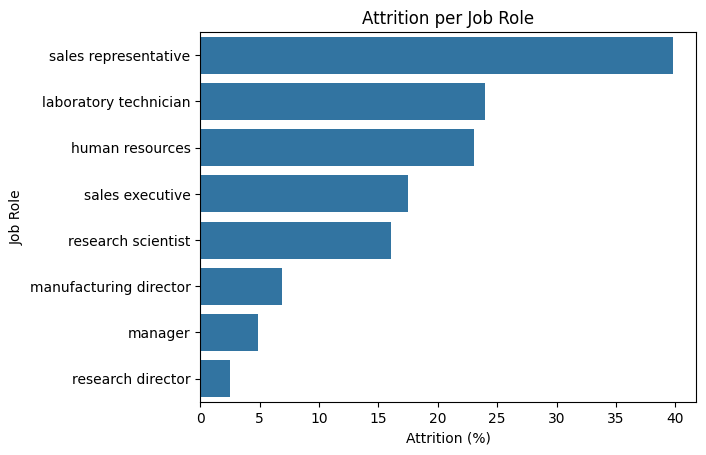

In [55]:
sns.barplot(
    x=jobrole_attrition.values,
    y=jobrole_attrition.index
)

plt.title("Attrition per Job Role")
plt.xlabel("Attrition (%)")
plt.ylabel("Job Role")
plt.show()

L'analisi del tasso di abbandono per ruolo evidenzia differenze importanti tra le mansioni. I ruoli più operativi e commerciali mostrano una maggiore probabilità di abbandono rispetto alle posizioni manageriali e direttive. In particolare, i Sales Representative e i Laboratory Technician risultano tra i ruoli più esposti all'attrition, mentre i ruoli senior come Manager e Research Director mostrano maggiore stabilità.

## **H2. MaritalStatus e OverTime**

H2. Fare straordinari e lo stato civile che influenza hanno sulla Atrrition?

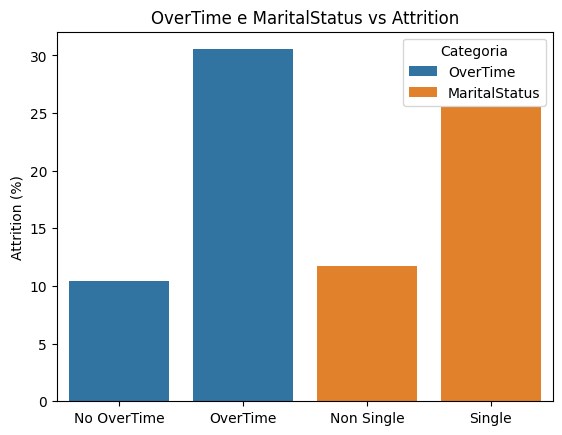

In [56]:
# calcolo tassi
overtime = employee_attrition_encoded.groupby("OverTime_yes")["Attrition"].mean()*100
marital = employee_attrition_encoded.groupby("MaritalStatus_single")["Attrition"].mean()*100

df_plot = pd.DataFrame({
    "Gruppo": [
        "No OverTime", "OverTime",
        "Non Single", "Single"
    ],
    "Attrition": [
        overtime.iloc[0],
        overtime.iloc[1],
        marital.iloc[0],
        marital.iloc[1]
    ],
    "Categoria": [
        "OverTime", "OverTime",
        "MaritalStatus", "MaritalStatus"
    ]
})


sns.barplot(
    data=df_plot,
    x="Gruppo",
    y="Attrition",
    hue="Categoria"
)

plt.title("OverTime e MaritalStatus vs Attrition")
plt.ylabel("Attrition (%)")
plt.xlabel("")
plt.show()

Il confronto mostra che sia lo svolgimento di straordinari sia lo stato civile single sono associati a un aumento del tasso di abbandono.

I risultati sono coerenti con l'analisi delle correlazioni: OverTime è la variabile con la correlazione positiva più alta con Attrition (r ≈ 0,25), mentre MaritalStatus_single mostra una correlazione positiva più moderata (r ≈ 0,18).

## **H3. WorkLifeBalance e Reddito mensile**

H3. Il reddito mensile cambia in base al WorkLifeBalance e all'Attrition?

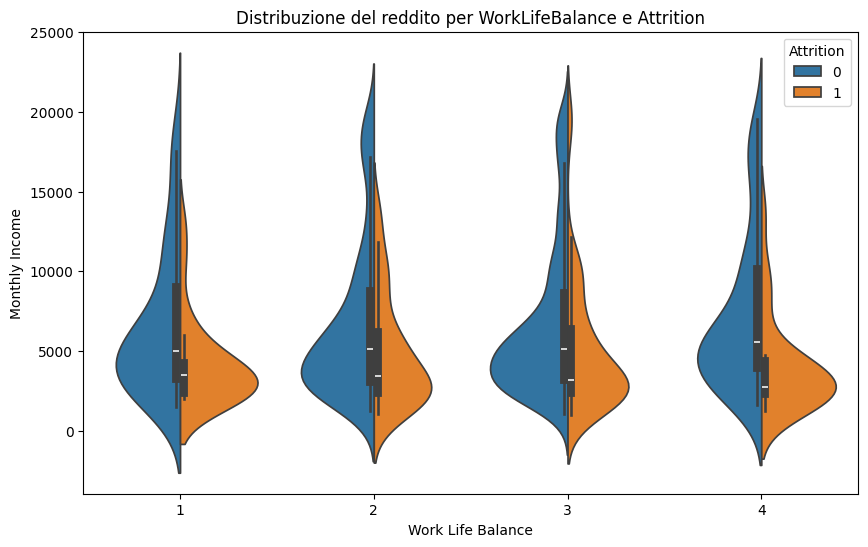

In [57]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=employee_attrition_encoded,
    x="WorkLifeBalance",
    y="MonthlyIncome",
    hue="Attrition",
    split=True
)

plt.title("Distribuzione del reddito per WorkLifeBalance e Attrition")
plt.xlabel("Work Life Balance")
plt.ylabel("Monthly Income")

plt.show()

Il violin plot mostra la distribuzione del reddito mensile in relazione al livello di WorkLifeBalance e all'attrition. I dipendenti che abbandonano l'azienda tendono a concentrarsi su livelli di reddito inferiori rispetto a chi rimane, indipendentemente dal livello di equilibrio vita-lavoro. Questo suggerisce che il reddito rappresenti un fattore rilevante nella permanenza aziendale.

## **H4. Age e MonthlyIncome**

H4. L'età del dipendente e il suo stipendio mensile influenzano l'abbandono?

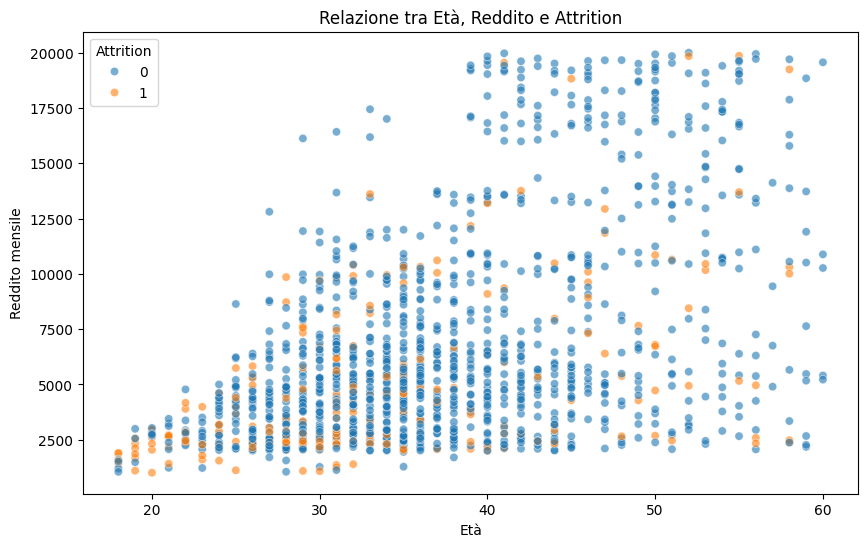

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=employee_attrition_encoded,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    alpha=0.6
)

plt.title("Relazione tra Età, Reddito e Attrition")
plt.xlabel("Età")
plt.ylabel("Reddito mensile")
plt.show()

Lo scatterplot evidenzia una relazione tra età, reddito mensile e attrition. I casi di abbandono risultano maggiormente concentrati tra i dipendenti più giovani e con redditi inferiori, mentre i dipendenti più anziani e con maggiore reddito mostrano una maggiore stabilità. Questo suggerisce che la combinazione tra esperienza lavorativa e posizione economica possa influenzare la permanenza nell'organizzazione.

## **H5. YearAtCompany e YearsSinceLastPromotion**

H5. I dipendenti che rimangono molti anni senza essere promossi hanno più probabilità di lasciare?

In [59]:
employee_attrition_encoded["PromotionDelayRatio"] = (
    employee_attrition_encoded["YearsSinceLastPromotion"] /
    (employee_attrition_encoded["YearsAtCompany"] + 1)
)

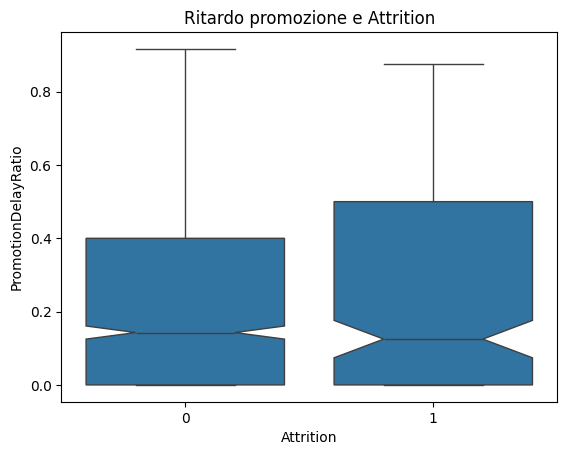

In [60]:
sns.boxplot(
    data=employee_attrition_encoded,
    x="Attrition",
    y="PromotionDelayRatio",
    notch=True
)

plt.title("Ritardo promozione e Attrition")
plt.show()

I dipendenti che hanno trascorso una quota maggiore della propria permanenza aziendale senza una promozione mostrano una maggiore probabilità di abbandono. Questo può indicare un effetto della percezione di limitate opportunità di carriera.

## **H6. Risk Score**

H6. Possiamo individuare un profilo di dipendente ad alto rischio?

In [61]:
employee_attrition_encoded["RiskScore"] = (
    employee_attrition_encoded["OverTime_yes"] +
    employee_attrition_encoded["MaritalStatus_single"] +
    (employee_attrition_encoded["JobSatisfaction"] <= 2).astype(int) +
    (employee_attrition_encoded["JobLevel"] == 1).astype(int)
)

In [62]:
employee_attrition_encoded.groupby(
    "RiskScore"
)["Attrition"].mean()*100

,Attrition
RiskScore,
0,7.220217
1,8.477237
2,24.200913
3,48.305085


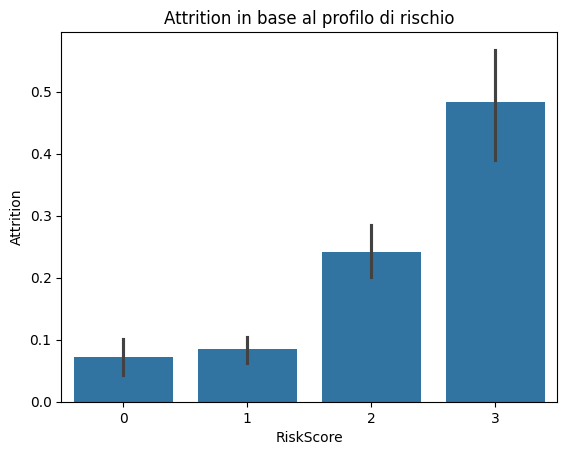

In [63]:
sns.barplot(
    data=employee_attrition_encoded,
    x="RiskScore",
    y="Attrition"
)

plt.title("Attrition in base al profilo di rischio")
plt.show()

L'attrition aumenta all'aumentare dei fattori di rischio combinati, suggerendo che il fenomeno dipenda dall'interazione di più condizioni.

In [64]:
#Salvo il dataset encoded
employee_attrition_encoded.to_csv("employee_attrition_encoded.csv", index=False)

In [65]:
import os
os.getcwd()

'/content'

# **Split Train / Test**

Dividiamo il dataset in training set (70%) e test set (30%). Usiamo stratify=y per mantenere in entrambi la stessa proporzione tra dipendenti rimasti e usciti, e random_state=42 per rendere lo split riproducibile.

In [66]:
from sklearn.model_selection import train_test_split

X = employee_attrition_encoded.drop(columns=["Attrition", "PromotionDelayRatio", "RiskScore"])
y = employee_attrition_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1029, 44)
Test set: (441, 44)


# **Scaling**

Standardizziamo le feature con StandardScaler. Lo scaler viene addestrato solo sul training set (fit_transform) e poi applicato al test set (transform), per evitare che informazioni del test influenzino la preparazione dei dati. La versione scalata servirà per Regressione Logistica e k-NN, mentre la Random Forest userà i dati non scalati.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_laboratory technician,JobRole_manager,JobRole_manufacturing director,JobRole_research director,JobRole_research scientist,JobRole_sales executive,JobRole_sales representative,MaritalStatus_married,MaritalStatus_single,OverTime_yes
853,-1.958919,-0.413973,-0.036578,-0.866067,0.270496,-0.547908,0.37805,-0.998363,-1.538894,-0.867017,...,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520
435,-0.430695,1.176070,0.699024,-1.835797,-0.651162,-0.449557,0.37805,0.846010,0.264662,1.532088,...,-0.463547,3.592409,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,1.551543
587,1.643324,1.296833,0.208623,1.073395,1.192155,0.829007,0.37805,-0.076177,0.264662,-0.737494,...,2.157277,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,-0.644520
1170,-1.085648,-0.549831,-0.894779,0.103664,1.192155,1.074884,0.37805,-0.998363,1.166440,-0.860942,...,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520
159,-0.321536,-1.274408,-0.894779,1.073395,0.270496,0.484778,0.37805,-0.998363,0.264662,-0.936660,...,-0.463547,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,4.334566,1.075748,-0.677919,-0.644520


# **I modelli di ML**

## Regressione logistica


Il primo modello è la Regressione Logistica, un modello lineare e interpretabile. Lo addestriamo sui dati scalati e lo valutiamo sul test set con accuracy, matrice di confusione e classification report (precision, recall, f1-score).

Accuracy Regressione Logistica: 0.880


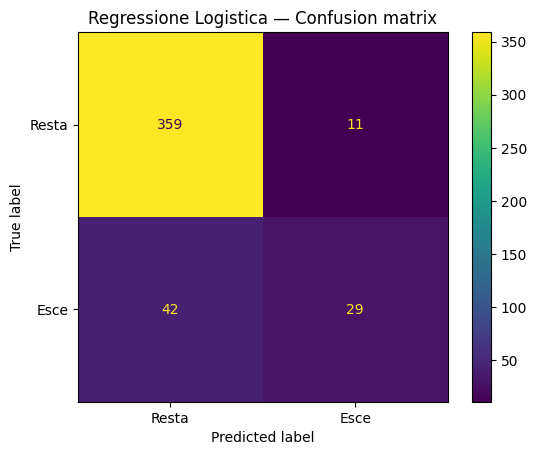

              precision    recall  f1-score   support

       Resta       0.90      0.97      0.93       370
        Esce       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441



In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)

acc_log = accuracy_score(y_test, pred_log)
print(f"Accuracy Regressione Logistica: {acc_log:.3f}")

cm_log = confusion_matrix(y_test, pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Resta", "Esce"])
disp.plot()
plt.title("Regressione Logistica — Confusion matrix")
plt.show()

print(classification_report(y_test, pred_log, target_names=["Resta", "Esce"]))

### Interpretazione

Il modello raggiunge un'accuracy dell'88%, ma questo valore va letto con cautela
per via dello sbilanciamento delle classi: poiché l'84% dei dipendenti resta, un
modello banale che prevedesse "Resta" per tutti otterrebbe già circa l'84% di
accuracy. È quindi più informativo guardare le metriche sulla classe "Esce", quella
di reale interesse. Qui la precision è 0.72 e il recall 0.41: il modello individua
il 41% dei dipendenti che effettivamente se ne vanno, e quando prevede "Esce" ha
ragione nel 72% dei casi. L'f1-score sulla classe "Esce" è 0.52, il più alto tra i
tre modelli.

## k-NN

Il secondo modello è il k-Nearest Neighbors, un modello non lineare che classifica ogni dipendente in base ai k casi più simili. Essendo basato sulle distanze, va addestrato sui dati scalati. Partiamo da k=5 come nei notebook visti a lezione.

Accuracy k-NN: 0.839


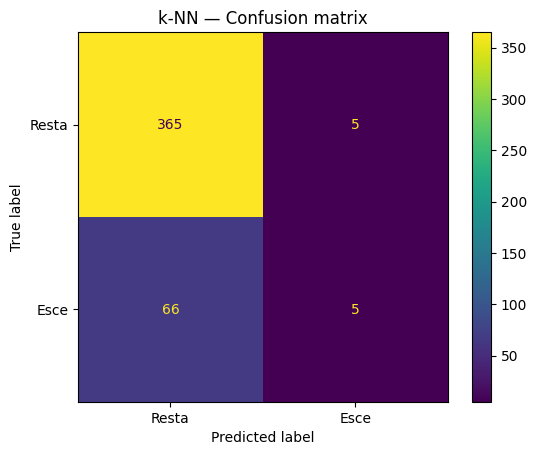

              precision    recall  f1-score   support

       Resta       0.85      0.99      0.91       370
        Esce       0.50      0.07      0.12        71

    accuracy                           0.84       441
   macro avg       0.67      0.53      0.52       441
weighted avg       0.79      0.84      0.78       441



In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, pred_knn)
print(f"Accuracy k-NN: {acc_knn:.3f}")

cm_knn = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Resta", "Esce"])
disp.plot()
plt.title("k-NN — Confusion matrix")
plt.show()

print(classification_report(y_test, pred_knn, target_names=["Resta", "Esce"]))

### Interpretazione

Pur avendo un'accuracy dell'84%, in linea con gli altri modelli, il k-NN risulta
poco utile per il nostro obiettivo. Il recall sulla classe "Esce" è solo 0.07: il
modello individua appena il 7% dei dipendenti che se ne vanno, classificando quasi
tutti come "Resta". Questo è un esempio chiaro di come l'accuracy possa essere
fuorviante con classi sbilanciate: il modello ottiene un valore alto semplicemente
assecondando la classe maggioritaria. L'f1-score sulla classe "Esce" è 0.12, il più
basso tra i tre modelli.

## Random Forest

Il terzo modello è la Random Forest, un modello non lineare basato su un insieme di alberi decisionali. Non è sensibile alla scala delle feature, quindi lo addestriamo sui dati NON scalati. Usiamo n_estimators=200 e random_state=42 per la riproducibilità.

Accuracy Random Forest: 0.834


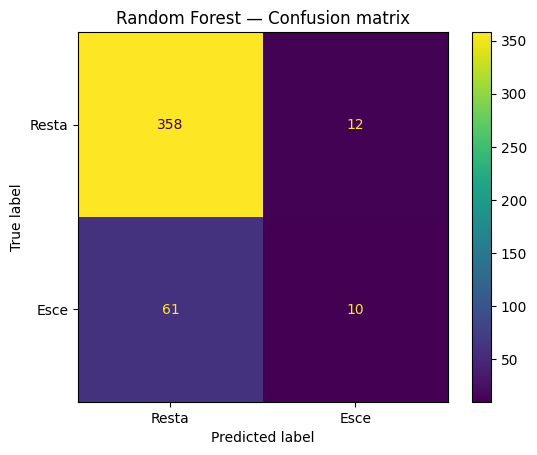

              precision    recall  f1-score   support

       Resta       0.85      0.97      0.91       370
        Esce       0.45      0.14      0.22        71

    accuracy                           0.83       441
   macro avg       0.65      0.55      0.56       441
weighted avg       0.79      0.83      0.80       441



In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.3f}")

cm_rf = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Resta", "Esce"])
disp.plot()
plt.title("Random Forest — Confusion matrix")
plt.show()

print(classification_report(y_test, pred_rf, target_names=["Resta", "Esce"]))

### Interpretazione

La Random Forest ottiene un'accuracy dell'83%, ma anche in questo caso le prestazioni
sulla classe "Esce" sono limitate: recall 0.14 e precision 0.45, per un f1-score di
0.22. Il modello individua quindi solo il 14% di chi se ne va. Pur essendo più
sofisticato del k-NN, non riesce a gestire bene lo sbilanciamento e resta nettamente
inferiore alla Regressione Logistica su questo problema.

# Confronto tra i modelli

Per confrontare i tre modelli li mettiamo a confronto sulle metriche principali.
Oltre all'accuracy complessiva riportiamo precision, recall e f1-score sulla classe
"Esce", che è quella di reale interesse e su cui lo sbilanciamento incide di più.

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

confronto = pd.DataFrame({
    "Modello": ["Regressione Logistica", "k-NN", "Random Forest"],
    "Accuracy": [acc_log, acc_knn, acc_rf],
    "Precision (Esce)": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_rf)
    ],
    "Recall (Esce)": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_rf)
    ],
    "F1 (Esce)": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_rf)
    ]
}).round(3)

confronto

,Modello,Accuracy,Precision (Esce),Recall (Esce),F1 (Esce)
0,Regressione Logistica,0.880,0.725,0.408,0.523
1,k-NN,0.839,0.500,0.070,0.123
2,Random Forest,0.834,0.455,0.141,0.215


### Interpretazione del confronto

I tre modelli hanno un'accuracy simile (0.83–0.88), ma questo valore è poco
informativo a causa dello sbilanciamento delle classi. Il confronto più significativo
è sull'f1-score della classe "Esce": la Regressione Logistica (0.52) supera nettamente
Random Forest (0.22) e k-NN (0.12). La Regressione Logistica è quindi il modello
migliore per questo problema, sia per capacità di individuare i dipendenti a rischio
(recall 0.41, il più alto) sia per affidabilità delle sue previsioni positive
(precision 0.72, la più alta). È un risultato interessante perché il modello più
semplice e interpretabile risulta anche il più efficace, a conferma che la complessità
di un modello non garantisce prestazioni migliori.

# Approfondimenti

## Coefficienti della Regressione logistica

Trattandosi di un modello lineare, la Regressione Logistica associa a ogni feature un
coefficiente. Un coefficiente positivo indica che la feature aumenta la probabilità di
abbandono ("Esce"), uno negativo che la riduce. Poiché il modello è stato addestrato
su dati standardizzati, i coefficienti sono confrontabili tra loro e il loro valore
assoluto indica il peso della feature. Riportiamo le feature con i coefficienti più
forti nelle due direzioni.

In [72]:
coef = pd.DataFrame({
    "feature": X.columns,
    "coefficiente": log_model.coef_[0]
}).sort_values("coefficiente", ascending=False)

# le 10 feature che spingono di più verso l'abbandono
print("Spingono verso l'abbandono (coefficiente positivo):")
print(coef.head(10).to_string(index=False))

print("\nRiducono la probabilità di abbandono (coefficiente negativo):")
print(coef.tail(10).to_string(index=False))

Spingono verso l'abbandono (coefficiente positivo):
                         feature  coefficiente
                    OverTime_yes      0.868609
BusinessTravel_travel_frequently      0.689218
   JobRole_laboratory technician      0.670609
         YearsSinceLastPromotion      0.616252
         JobRole_sales executive      0.613567
    JobRole_sales representative      0.558015
              NumCompaniesWorked      0.491335
            MaritalStatus_single      0.401519
    BusinessTravel_travel_rarely      0.395709
                DistanceFromHome      0.356526

Riducono la probabilità di abbandono (coefficiente negativo):
                     feature  coefficiente
        EducationField_other     -0.339968
              JobInvolvement     -0.347294
    RelationshipSatisfaction     -0.372609
EducationField_life sciences     -0.389313
      EducationField_medical     -0.397371
                         Age     -0.421568
             JobSatisfaction     -0.430645
          YearsInCurrent

### Interpretazione

I coefficienti delineano un profilo di rischio coerente. I fattori che aumentano di
più la probabilità di abbandono sono lo straordinario (OverTime), i viaggi di lavoro
frequenti, alcuni ruoli specifici (laboratory technician, sales executive e
representative), il tempo trascorso dall'ultima promozione, il numero di aziende
precedenti e l'essere single. In direzione opposta, trattengono il dipendente le
varie forme di soddisfazione (ambiente, lavoro, relazioni) e il coinvolgimento, oltre
alle variabili legate all'anzianità e all'età (anni di lavoro totali, anni nel ruolo
attuale, età). Il modello individua quindi come più a rischio un dipendente giovane,
single, con molti straordinari e viaggi, fermo da tempo a livello di promozioni; come
più stabile un dipendente più anziano, soddisfatto e radicato nel proprio ruolo. La
leggibilità di questi coefficienti è uno dei principali punti di forza della
Regressione Logistica.

## La feature importance della Random Forest

La Random Forest permette di misurare la feature importance, ovvero quanto ogni
feature contribuisce a separare le classi all'interno degli alberi. A differenza dei
coefficienti della Regressione Logistica, la feature importance non indica la
direzione dell'effetto (non distingue tra fattori che spingono o trattengono), ma solo
il peso complessivo della feature nelle decisioni del modello. Riportiamo le 10 feature
più importanti.

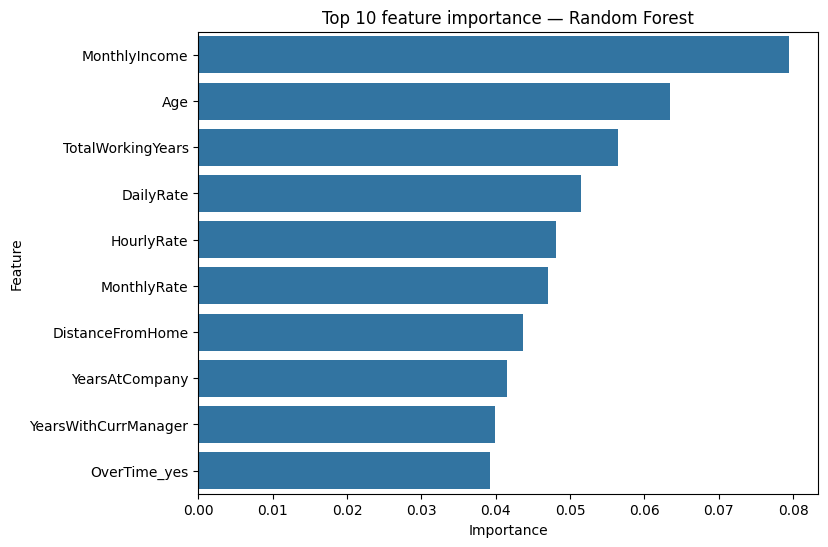

,feature,importance
9,MonthlyIncome,0.079422
0,Age,0.063437
16,TotalWorkingYears,0.056514
1,DailyRate,0.051529
5,HourlyRate,0.048064
10,MonthlyRate,0.047042
2,DistanceFromHome,0.043657
19,YearsAtCompany,0.041499
22,YearsWithCurrManager,0.039863
43,OverTime_yes,0.039287


In [73]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance.head(10), x="importance", y="feature")
plt.title("Top 10 feature importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance.head(10)

### Interpretazione

La Random Forest assegna le importanze più alte a variabili numeriche e continue
(MonthlyIncome, Age, TotalWorkingYears, le varie tariffe, DistanceFromHome, anzianità).
Il confronto con i coefficienti della Regressione Logistica è interessante: i due
modelli concordano su alcuni temi di fondo (retribuzione, età, anzianità, straordinari),
ma li pesano diversamente. La Random Forest tende a privilegiare le variabili continue
perché offrono molti possibili punti di taglio negli alberi, mentre la Regressione
Logistica dava grande peso a variabili binarie come OverTime o lo stato civile. Va
inoltre notato che tra le feature più importanti compaiono HourlyRate, DailyRate e
MonthlyRate, variabili che in fase esplorativa non mostravano una relazione chiara con
l'abbandono: questo conferma che la feature importance va interpretata con cautela,
perché tende a premiare le variabili continue a prescindere dalla loro reale utilità
predittiva, come mostra anche l'esperimento con una feature casuale visto a lezione.